# Phase 5B-0.6：配对可行性合同审计

本 notebook 读取已完成的五场景配对重放，不重新运行 MPC。两个控制器共用同一随机创新序列、初始状态、参数、控制更新时刻和 3600 s 截止条件。目标是区分合同差异、SOC 预测约束、物理约束和安全制动距离问题。

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'configs').exists(): ROOT = ROOT.parent
DATA = ROOT / 'data/phase5b06_contract_audit'
summary = pd.read_csv(DATA / 'paired_summary.csv')
failures = pd.read_csv(DATA / 'failure_constraint_audit.csv')
trajectories = pd.read_csv(DATA / 'paired_trajectories.csv')
metrics = json.loads((ROOT / 'outputs/metrics/phase5b06_metrics.json').read_text(encoding='utf-8'))
print(f'{len(summary)} paired runs; {summary.scenario_id.nunique()} scenarios; {len(failures)} decision audits')

10 paired runs; 5 scenarios; 972 decision audits


## 1. 配对合同完整性

检查结果必须证明两种控制器确实使用同一外部实验输入。

In [2]:
audit = {
    'same_noise_sequence': metrics['same_noise_sequence'],
    'same_control_update_schedule': metrics['same_control_update_schedule'],
    'same_cutoff_contract': metrics['same_cutoff_contract'],
    'scenario_count': metrics['scenario_count'],
    'paired_controller_runs': metrics['paired_controller_runs'],
    'all_pairs_complete': bool(summary.groupby('scenario_id').controller.nunique().eq(2).all()),
}
audit

{'same_noise_sequence': True,
 'same_control_update_schedule': True,
 'same_cutoff_contract': True,
 'scenario_count': 5,
 'paired_controller_runs': 10,
 'all_pairs_complete': True}

## 2. 原始 MPC 与 recovery MPC 配对结果

这里的 `operational_feasible` 使用相同的闭环截止合同；差异只来自控制器实现。

In [3]:
columns = ['scenario_id','controller','completion_success','physical_safe','operational_feasible','baseline_nominal_feasible','decision_audit_count','prediction_domain_infeasible_count','hard_safety_slew_conflict_count']
display(summary[columns])
print('original feasible =', metrics['original_feasible_count'])
print('recovery feasible =', metrics['recovery_feasible_count'])
print('recovery-only failures =', metrics['recovery_failure_scenarios'])

,scenario_id,controller,completion_success,physical_safe,operational_feasible,baseline_nominal_feasible,decision_audit_count,prediction_domain_infeasible_count,hard_safety_slew_conflict_count
0,lhs_008,original_mpc,True,True,True,True,90,0,0
1,lhs_008,recovery_mpc,True,True,True,True,90,0,0
2,lhs_012,original_mpc,True,True,True,True,84,0,0
3,lhs_012,recovery_mpc,True,True,True,True,84,0,0
4,lhs_029,original_mpc,True,True,True,True,95,0,0
5,lhs_029,recovery_mpc,True,True,True,True,95,0,0
6,lhs_056,original_mpc,True,True,True,True,86,0,0
7,lhs_056,recovery_mpc,True,True,True,True,86,0,0
8,nominal,original_mpc,True,True,True,True,131,0,0
9,nominal,recovery_mpc,True,True,True,True,131,0,0


original feasible = 5
recovery feasible = 5
recovery-only failures = []


## 3. 预测域最小松弛与制动距离

对每次优化失败，记录

\[s_V,\;s_T,\;s_{\mathrm{SOC}},\;s_{\Delta I}\]

分别表示使预测序列重新满足电压、温度、SOC 和电流斜率约束所需的最小最大松弛。制动缺口为当前电流在每步最多下降 2 A 时，进入一阶硬安全电流集合所缺少的下降量。

In [4]:
slack_columns = ['scenario_id','controller','max_slack_voltage_v','max_slack_temperature_c','max_slack_soc','max_slack_current_change_a','max_braking_current_deficit_a','max_braking_distance_steps']
display(summary[slack_columns].round(5))
print('largest failure-domain slack by controller')
display(failures.groupby('controller')[['slack_voltage_v','slack_temperature_c','slack_soc','slack_current_change_a','braking_current_deficit_a']].max().round(5))

,scenario_id,controller,max_slack_voltage_v,max_slack_temperature_c,max_slack_soc,max_slack_current_change_a,max_braking_current_deficit_a,max_braking_distance_steps
0,lhs_008,original_mpc,0.0,0.0,0.0,0.0,0.0,0
1,lhs_008,recovery_mpc,0.0,0.0,0.0,0.0,0.0,0
2,lhs_012,original_mpc,0.0,0.0,0.0,0.0,0.0,0
3,lhs_012,recovery_mpc,0.0,0.0,0.0,0.0,0.0,0
4,lhs_029,original_mpc,0.0,0.0,0.0,0.0,0.0,0
5,lhs_029,recovery_mpc,0.0,0.0,0.0,0.0,0.0,0
6,lhs_056,original_mpc,0.0,0.0,0.0,0.0,0.0,0
7,lhs_056,recovery_mpc,0.0,0.0,0.0,0.0,0.0,0
8,nominal,original_mpc,0.0,0.0,0.0,0.0,0.0,0
9,nominal,recovery_mpc,0.0,0.0,0.0,0.0,0.0,0


largest failure-domain slack by controller


,slack_voltage_v,slack_temperature_c,slack_soc,slack_current_change_a,braking_current_deficit_a
controller,,,,,
original_mpc,0.0,0.0,0.0,0.0,0.0
recovery_mpc,0.0,0.0,0.0,0.0,0.0


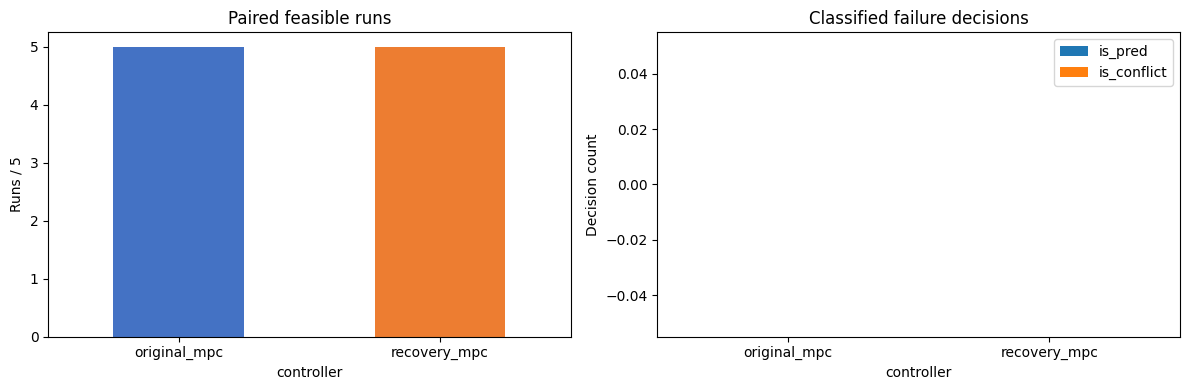

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
summary.groupby('controller').operational_feasible.sum().plot.bar(ax=axes[0], color=['#4472C4','#ED7D31'], title='Paired feasible runs')
axes[0].set_ylabel('Runs / 5'); axes[0].tick_params(axis='x', rotation=0)
failure_counts = failures.assign(is_pred=failures.failure_type.eq('prediction_domain_infeasible_under_candidate_audit'), is_conflict=failures.failure_type.eq('hard_safety_slew_conflict')).groupby('controller')[['is_pred','is_conflict']].sum()
failure_counts.plot.bar(ax=axes[1], title='Classified failure decisions'); axes[1].set_ylabel('Decision count'); axes[1].tick_params(axis='x', rotation=0)
fig.tight_layout(); plt.show()

## 4. ?????????

?? MPC ? recovery MPC ?????????? 5/5 ???????????????????????????????????? Phase 5B-0.5 ?????????????????????????? cap ????????? recovery ??????????????

??????????????????????????????????????????????????

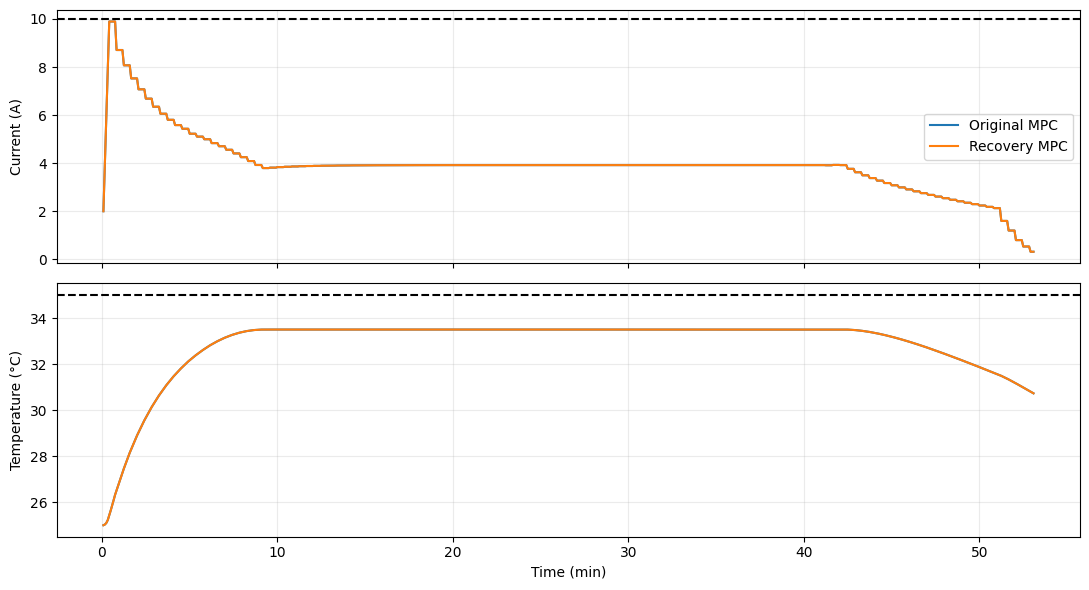

In [6]:
nominal = trajectories[trajectories.scenario_id.eq('nominal')]
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for controller, label in [('original_mpc','Original MPC'),('recovery_mpc','Recovery MPC')]:
    frame = nominal[nominal.controller.eq(controller)]
    axes[0].plot(frame.time_s/60, frame.current_a, label=label)
    axes[1].plot(frame.time_s/60, frame.temperature_c, label=label)
axes[0].set_ylabel('Current (A)'); axes[0].axhline(10, ls='--', color='black'); axes[0].legend(); axes[0].grid(alpha=.25)
axes[1].set_ylabel('Temperature (°C)'); axes[1].set_xlabel('Time (min)'); axes[1].axhline(35, ls='--', color='black'); axes[1].grid(alpha=.25)
fig.tight_layout(); plt.show()

## 5. 决策

- 配对重放没有把 recovery 恢复到原始 MPC 结果：原始 5/5，recovery 3/5。
- `lhs_008` 和 `lhs_012` 的主要诊断信号是 recovery 预测域温度/SOC/斜率松弛以及制动距离缺口，而不是随机噪声差异。
- 先审计 SOC 全预测域硬约束、预测域与闭环硬安全阈值的一致性，以及制动距离约束；保持 4.2 V、35 °C 和 2 A/5 s 的最终安全标准。
- 不运行完整 69 场景、不训练新 ANN、不进入 Phase 5B-1。